In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import re

In [4]:
df = pd.read_csv('merged_horse_racing_data.csv')

In [9]:
import re
from datetime import datetime 
# Building Features


def create_target_variable(df_in):
    """Create winner column from race position (1 if position is 1, 0 otherwise)"""
    # Create the 'winner' column directly on the DataFrame
    # print(df_in['race_position_clean'].shape())
    df_in['winner'] = (df_in['race_position_clean'] == 1).astype(int)
    return df_in


def create_going_features(df):
    """
    Creates temporal going/track condition features WITHOUT data leakage.
    
    Args:
        df: DataFrame with columns: horse_name_clean, going, race_date (or track_name to extract from)
    
    Returns:
        DataFrame with added going performance features
    """


def create_going_features(df):
    """
    Creates temporal going/track condition features WITHOUT data leakage.
    
    Args:
        df: DataFrame with columns: horse_name_clean, going, race_date (or track_name to extract from)
    
    Returns:
        DataFrame with added going performance features
    """
    df = df.copy()
    
    # Going scale for encoding
    GOING_SCALE = [
        "Firm", "Good to Firm", "Good", "Good to Yielding",
        "Yielding", "Yielding to Soft", "Soft", "Soft to Heavy",
        "Heavy", "Standard"
    ]
    
    def extract_clean_going(raw_going):
        """Extract standardized going from raw text"""
        if not isinstance(raw_going, str):
            return None
        
        raw = raw_going.lower().replace('-', ' ').strip()
        
        # Check multi-word matches first (longest first)
        for going in sorted(GOING_SCALE, key=lambda g: -len(g)):
            pattern = r'\b' + re.escape(going.lower()) + r'\b'
            if re.search(pattern, raw):
                return going
        
        # Check individual words
        tokens = re.findall(r'\b\w+\b', raw)
        for token in tokens:
            for going in GOING_SCALE:
                if token == going.lower():
                    return going
        return None
    
    # Clean going column
    if 'going' in df.columns:
        df['going_clean'] = df['going'].str.split('(').str[0].str.strip()
        df['going_clean'] = df['going_clean'].apply(extract_clean_going)
    
    # Ensure race_date exists
    if 'race_date' not in df.columns or df['race_date'].isna().all():
        def parse_date(track_name):
            if not isinstance(track_name, str):
                return None
            parts = track_name.split('|', 1)
            if len(parts) < 2:
                return None
            cleaned = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', parts[-1])
            try:
                return datetime.strptime(cleaned.strip(), "%d %B %Y %H:%M")
            except:
                return None
        
        df['race_date'] = df['track_name'].apply(parse_date)
    
    df['race_date'] = pd.to_datetime(df['race_date'], errors='coerce')
    
    # Create winner label if not exists
    if 'winner' not in df.columns:
        df['winner'] = (df['race_position_clean'] == 1).astype(int)
    
    # Sort for temporal calculations
    df = df.sort_values(['horse_name_clean', 'race_date']).reset_index(drop=True)
    
    # Create performance_on_{going_type} features
    going_types = df['going_clean'].dropna().unique()
    
    for going_type in going_types:
        feature_name = f'performance_on_{going_type.replace(" ", "_")}'
        
        # Mask for this going type
        going_mask = df['going_clean'] == going_type
        
        # Binary indicators
        df['_temp_win_on_going'] = (going_mask & (df['winner'] == 1)).astype(int)
        df['_temp_race_on_going'] = going_mask.astype(int)
        
        # Cumulative stats per horse
        grouped = df.groupby('horse_name_clean')
        cumsum_wins = grouped['_temp_win_on_going'].cumsum()
        cumsum_races = grouped['_temp_race_on_going'].cumsum()
        
        # Shift to exclude current race
        wins_before = cumsum_wins - df['_temp_win_on_going']
        races_before = cumsum_races - df['_temp_race_on_going']
        
        # Calculate win rate
        df[feature_name] = np.where(races_before > 0, wins_before / races_before, 0.0)
        
        # Clean up temp columns
        df.drop(['_temp_win_on_going', '_temp_race_on_going'], axis=1, inplace=True)
    
    # Add numeric going encoding
    going_to_num = {going: idx for idx, going in enumerate(GOING_SCALE)}
    df['going_numeric'] = df['going_clean'].map(going_to_num)
    
    return df

def _extract_race_date(track_name):
    """Extract race date from track_name column"""
    if not isinstance(track_name, str):
        return None
    
    new = track_name.split('|', 1)[-1]
    cleaned_string = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', new)
    
    # DEBUG: Print what we're actually trying to parse
    # print(f"Trying to parse: '{cleaned_string}'")
    
    try:
        date_object = datetime.strptime(cleaned_string, " %d %B %Y %H:%M")
        return date_object.strftime("%d/%m/%Y")
    except ValueError as e:
        # print(f"First format failed: {e}")
        try:
            date_object = datetime.strptime(cleaned_string, " %d %B %Y %H")
            return date_object.strftime("%d/%m/%Y")
        except ValueError as e:
            # print(f"Second format failed: {e}")
            return None



def create_jt_temporal_features(df) -> pd.DataFrame:
    """
    Creates the temporal J/T runs and wins features.
    Returns:
        The DataFrame with the new temporal features appended.
    """
    jockey_col = 'jockey_clean'
    trainer_col = 'trainer_clean'
    winner_col = 'winner'
    track_name_col = 'track_name'

    # Save the initial length to correctly report dropped rows
    initial_length = len(df)
    df = df.copy()

    # 1. Create the unique J/T combination feature (j_t)
    df['j_t'] = df[jockey_col].astype(str) + '__' + df[trainer_col].astype(str)
    print("✓ 'j_t' feature created.")

    # 2. Extract and convert the date for temporal sorting
    df['race_date_str'] = df[track_name_col].apply(_extract_race_date)
    
    # Convert to datetime object for accurate sorting, coercing errors to NaT
    df['race_datetime'] = pd.to_datetime(df['race_date_str'], format='%d/%m/%Y', errors='coerce')
    
    # Drop rows where date parsing failed
    df.dropna(subset=['race_datetime'], inplace=True)
    print(f"✓ Race dates parsed. Removed {initial_length - len(df)} rows with invalid dates.")

    # 3. Sort the DataFrame by the race date (critical for temporal logic)
    # Note: If two races happen on the same date, the internal row order is used,
    # which is usually fine for cumulative calculations.
    df.sort_values(by='race_datetime', inplace=True)
    print("✓ DataFrame sorted temporally.")

    # 4. Temporal Feature Calculation (Groupby + Cumulative + Shift)

    # j_t_runs: The number of times this J/T pair ran BEFORE the current race.
    # cumcount() starts at 0 for the first item in a group.
    df['j_t_runs'] = df.groupby('j_t').cumcount()

    # j_t_wins: The number of wins this J/T pair had BEFORE the current race.
    # shift(1) ensures the current race result is excluded (look-ahead free).
    df['j_t_wins'] = df.groupby('j_t')[winner_col].cumsum().shift(1).fillna(0).astype(int)

    print("✓ Temporal features 'j_t_runs' and 'j_t_wins' created.")
    
    # 5. Calculate j_t_win_rate (avoid division by zero)
    df['j_t_win_rate'] = np.where(
        df['j_t_runs'] > 0,
        df['j_t_wins'] / df['j_t_runs'],
        0.0
    )
    print("✓ 'j_t_win_rate' calculated.")

    # 6. Clean up temporary columns - ADDED errors='ignore' for safety
    df.drop(columns=['race_date_str', 'race_datetime'], inplace=True, errors='ignore')
    print("✓ Temporary columns cleaned up.")
    
    return df


def avg_Position_Horse(df):
    print("Creating avg_position...")
    df['avg_position'] = (df.groupby('horse_name_clean')['race_position_clean']
                            .shift(1)
                            .groupby(df['horse_name_clean'])
                            .expanding()
                            .mean()
                            .reset_index(level=0, drop=True))
    return df

def days_Since_Last_Win_Horse(df):
    df = df.sort_values(['horse_name_clean', 'race_date']).reset_index(drop=True)
    df['days_since_last_race'] = df.groupby('horse_name_clean')['race_date'].diff().dt.days
    df['days_since_last_race'] = df['days_since_last_race'].fillna(0)

    df['last_win_date'] = df[df['winner'] ==True].groupby('horse_name_clean')['race_date'].shift(1)
    df['last_win_date'] = df.groupby('horse_name_clean')['last_win_date'].ffill()
    df['days_since_last_win'] = (df['race_date'] - df['last_win_date']).dt.days
    df.drop(columns = "last_win_date")

# --- _extract_race_date remains the same ---
def _extract_race_date(track_name):
    """Extract race date from track_name column"""
    if not isinstance(track_name, str):
        return None

    new = track_name.split('|', 1)[-1]
    cleaned_string = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', new)

    try:
        date_object = datetime.strptime(cleaned_string, " %d %B %Y %H:%M")
        return date_object
    except ValueError:
        try:
            date_object = datetime.strptime(cleaned_string, " %d %B %Y %H")
            return date_object
        except ValueError:
            return None

# --- normalize_distance function (assuming it exists from your original code) ---
# Placeholder - replace with your actual function if different
def normalize_distance(df):
    print("Assuming normalize_distance function exists and creates 'distance_normalized'.")
    # Example placeholder logic if 'distance' is in yards:
    if 'distance' in df.columns and 'distance_normalized' not in df.columns:
         # Basic check if it looks like furlongs/miles string
        if df['distance'].dtype == 'object':
             print("Warning: 'distance' is object type, attempting basic conversion.")
             # Very basic example, replace with your robust logic
             def rough_dist_conv(d):
                 try:
                     if 'm' in d and 'f' in d:
                         m, f = map(int, re.findall(r'(\d+)m|(\d+)f', d)[0])
                         return m * 1760 + f * 220
                     elif 'f' in d:
                         f = int(re.findall(r'(\d+)f', d)[0])
                         return f * 220
                     elif 'm' in d:
                          m = int(re.findall(r'(\d+)m', d)[0])
                          return m * 1760
                     return np.nan # Or handle other cases
                 except:
                     return np.nan
             df['distance_normalized'] = df['distance'].apply(rough_dist_conv)
        elif pd.api.types.is_numeric_dtype(df['distance']):
             print("Assuming 'distance' is already numeric (yards). Using as 'distance_normalized'.")
             df['distance_normalized'] = df['distance'] # Or apply your specific normalization
        else:
             print("Error: Cannot normalize distance. Unknown format.")
             # Create dummy column to avoid errors later, but this needs fixing
             df['distance_normalized'] = np.nan
    elif 'distance_normalized' not in df.columns:
        print("Error: 'distance' or 'distance_normalized' column not found.")
        df['distance_normalized'] = np.nan # Create dummy column
    return df


# --- MODIFIED: calculate_preferred_distance_temporal_fast ---
def calculate_preferred_distance_temporal_fast(df):
    """
    Calculate different versions of horse's preferred distance based ONLY on past races.
    - preferred_distance_top3_only: Avg distance of past top 3 finishes (NaN if none).
    - avg_past_distance_all: Avg distance of ALL valid past races (NaN if none).
    - preferred_distance_fallback: Uses top3, falls back to all if no top3 yet.
    """
    # Sort by horse and date
    df = df.sort_values(['horse_name_clean', 'race_date']).reset_index(drop=True)

    print("Sample of data (sorted by date):")
    print(df[['horse_name_clean', 'race_date', 'race_position_clean', 'distance_normalized']].head(10))
    print(f"\nTotal rows before calculations: {len(df)}")

    # Create helper columns
    df['valid_race'] = (df['race_position_clean'] >= 1) & (df['distance_normalized'].notna())
    df['top_3_finish'] = (df['race_position_clean'] <= 3) & df['valid_race']
    df['distance_x_top3'] = df['distance_normalized'].where(df['top_3_finish'], 0) # Use where for clarity
    df['distance_x_valid'] = df['distance_normalized'].where(df['valid_race'], 0) # Use where for clarity

    print("Calculating expanding statistics...")
    grouped = df.groupby('horse_name_clean', group_keys=False) # group_keys=False is slightly faster

    # --- Calculate cumulative counts and sums (using transform for efficiency) ---
    # Shift(1) ensures we only use PAST races
    df['cumsum_top3'] = grouped['top_3_finish'].transform(lambda x: x.shift(1, fill_value=0).cumsum())
    df['cumsum_distance_top3'] = grouped['distance_x_top3'].transform(lambda x: x.shift(1, fill_value=0).cumsum())
    df['cumsum_races_run'] = grouped['valid_race'].transform(lambda x: x.shift(1, fill_value=0).cumsum())
    df['cumsum_distance_all'] = grouped['distance_x_valid'].transform(lambda x: x.shift(1, fill_value=0).cumsum())

    # --- Calculate the different preferred distance metrics ---

    # 1. Original: Average distance of past top 3 finishes (NaN if none)
    temp_denom_top3 = df['cumsum_top3'].replace(0, np.nan)
    df['preferred_distance_top3_only'] = df['cumsum_distance_top3'] / temp_denom_top3

    # 2. Alternative A: Average distance of ALL valid past races (NaN if none)
    temp_denom_all = df['cumsum_races_run'].replace(0, np.nan)
    df['avg_past_distance_all'] = df['cumsum_distance_all'] / temp_denom_all

    # 3. Alternative B (Fallback): Use top3 average, but use 'all race average' if no prior top 3
    # We can use fillna here because preferred_distance_top3_only is already NaN where cumsum_top3 is 0
    df['preferred_distance_fallback'] = df['preferred_distance_top3_only'].fillna(df['avg_past_distance_all'])

    print(f"Preferred distances (top3 only) calculated for {df['preferred_distance_top3_only'].notna().sum()} races")
    print(f"Average past distances (all) calculated for {df['avg_past_distance_all'].notna().sum()} races")
    print(f"Preferred distances (fallback) calculated for {df['preferred_distance_fallback'].notna().sum()} races")

    # Clean up temporary columns
    df = df.drop(columns=['valid_race', 'top_3_finish', 'distance_x_top3', 'distance_x_valid',
                          'cumsum_top3', 'cumsum_distance_top3', 'cumsum_races_run', 'cumsum_distance_all'])

    return df

# --- MODIFIED: calculate_distance_match_and_correlation ---
def calculate_distance_match_and_correlation(df, pref_dist_col):
    """
    Calculate if current distance matches a specific preferred distance column
    and compute correlation with winning.

    Args:
        df (pd.DataFrame): DataFrame containing results and the preferred distance column.
        pref_dist_col (str): The name of the preferred distance column to analyze.

    Returns:
        tuple: (DataFrame used for analysis, dict containing correlation stats)
    """
    print(f"\n--- Analyzing Preferred Distance Column: {pref_dist_col} ---")

    # Ensure winner column exists
    if 'winner' not in df.columns:
        df['winner'] = (df['race_position_clean'] == 1).astype(int)

    # Calculate absolute difference using the specified preferred distance column
    df[f'{pref_dist_col}_diff'] = np.abs(df[pref_dist_col] - df['distance_normalized'])

    # Create binary feature: is distance within tolerance of preferred?
    tolerance = 220  # yards
    df[f'{pref_dist_col}_match'] = (df[f'{pref_dist_col}_diff'] <= tolerance).astype(int)

    # --- Analysis Part ---
    # Remove rows where we don't have the specific preferred distance or winner
    df_analysis = df.dropna(subset=[pref_dist_col, 'winner', f'{pref_dist_col}_diff']).copy() # Use copy to avoid SettingWithCopyWarning in plotting

    if df_analysis.empty:
        print("No valid races for analysis after dropping NaNs.")
        return df_analysis, {} # Return empty results

    print("\n" + "="*60)
    print(f"DISTANCE MATCH ANALYSIS ({pref_dist_col})")
    print("="*60)
    print(f"Total races analyzed: {len(df_analysis)}")
    match_col = f'{pref_dist_col}_match'
    diff_col = f'{pref_dist_col}_diff'
    print(f"Races with distance match: {df_analysis[match_col].sum()}")
    print(f"Races without distance match: {len(df_analysis) - df_analysis[match_col].sum()}")

    # Calculate win rates
    overall_win_rate = df_analysis['winner'].mean()
    # Handle cases where one category might be empty (though unlikely with NaN drop)
    win_rate_with_match = df_analysis[df_analysis[match_col] == 1]['winner'].mean() if (df_analysis[match_col] == 1).any() else 0
    win_rate_without_match = df_analysis[df_analysis[match_col] == 0]['winner'].mean() if (df_analysis[match_col] == 0).any() else 0

    print(f"\nOverall win rate: {overall_win_rate:.4f} ({overall_win_rate*100:.2f}%)")
    print(f"Win rate when distance matches: {win_rate_with_match:.4f} ({win_rate_with_match*100:.2f}%)")
    print(f"Win rate when distance doesn't match: {win_rate_without_match:.4f} ({win_rate_without_match*100:.2f}%)")
    print(f"Lift: {(win_rate_with_match/overall_win_rate) if overall_win_rate > 0 else 'N/A'}") # Avoid division by zero for lift

    results = {
        'overall_win_rate': overall_win_rate,
        'win_rate_with_match': win_rate_with_match,
        'win_rate_without_match': win_rate_without_match
    }


    return df_analysis, 


# === Main Execution ===

# Load data

# Extract and convert race_date to datetime

# Normalize distance
print("Normalizing distances...")
df = normalize_distance(df) # Make sure this function exists and works
print(f"Rows after distance normalization & dropna: {len(df)}")


# Calculate preferred distance variants with temporal awareness
print("\nCalculating preferred distances using only past races (VECTORIZED)...")
df = calculate_preferred_distance_temporal_fast(df)


print(df.head(0))
df = create_target_variable(df)
df['race_date'] = df['track_name'].apply(_extract_race_date)
print(df['race_date'])
df = create_going_features(df)
df = create_jt_temporal_features(df)
df = avg_Position_Horse(df)
# print(df.head(0))
columns_to_drop = [
        "race_time",
        "race_date",
        "going",
        "race_position",
        "lost_by_length",
        "lost_by_length_clean",
        "rating",
        "first_place_found",
        "batch_number",
        "url_index_in_batch",
        "source_file",
        "race_position_clean",
        "rating_clean",
        "race_time_clean",
        "first_place_found_clean",
        "winner",
        "distance",
        "horse_name",
        "jockey",
        "trainer",
        "age",
        "weight",
        "horse_name_clean",

]


X = df.drop(columns = columns_to_drop, axis=1)
Y = df['winner']
print(X.head(0))

Normalizing distances...
Assuming normalize_distance function exists and creates 'distance_normalized'.
Rows after distance normalization & dropna: 42758

Calculating preferred distances using only past races (VECTORIZED)...
Sample of data (sorted by date):
           horse_name_clean           race_date  race_position_clean  \
0    A Brandy For Bob (IRE) 2024-04-22 16:35:00                    9   
1     A Call Too Soon (IRE) 2024-08-02 17:30:00                    9   
2     A Call Too Soon (IRE) 2024-08-17 14:50:00                   -1   
3     A Call Too Soon (IRE) 2024-10-09 13:51:00                   15   
4  A Chuisle Mo Chroi (IRE) 2022-06-03 20:20:00                    8   
5          A Daughters Love 2025-03-28 19:00:00                    8   
6          A Daughters Love 2025-05-06 16:38:00                   10   
7  A Daughtersdelight (IRE) 2023-06-03 14:25:00                   13   
8  A Daughtersdelight (IRE) 2023-06-03 14:25:00                   13   
9  A Daughtersdelight 

/var/folders/j_/qzpvcxbn139f7y12swzzsdw40000gn/T/ipykernel_23698/1337048084.py:328: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp_denom_top3 = df['cumsum_top3'].replace(0, np.nan)
/var/folders/j_/qzpvcxbn139f7y12swzzsdw40000gn/T/ipykernel_23698/1337048084.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp_denom_all = df['cumsum_races_run'].replace(0, np.nan)


Preferred distances (top3 only) calculated for 17132 races
Average past distances (all) calculated for 30380 races
Preferred distances (fallback) calculated for 30380 races
Empty DataFrame
Columns: [track_name, race_date, race_time, going, distance, horse_name, jockey, claims, trainer, race_position, lost_by_length, age, weight, rating, first_place_found, batch_number, url_index_in_batch, source_file, race_position_clean, lost_by_length_clean, rating_clean, weight_clean, track_name_clean, race_date_clean, race_time_clean, going_clean, distance_clean, horse_name_clean, jockey_clean, trainer_clean, claims_clean, age_clean, first_place_found_clean, distance_normalized, preferred_distance_top3_only, avg_past_distance_all, preferred_distance_fallback, winner, performance_on_Good, performance_on_Yielding_to_Soft, performance_on_Good_to_Yielding, performance_on_Soft, performance_on_Standard, performance_on_Yielding, performance_on_Soft_to_Heavy, performance_on_Heavy, performance_on_Good_to_Fi

Preparing data...
Empty DataFrame
Columns: [track_name, claims, weight_clean, track_name_clean, race_date_clean, going_clean, distance_clean, jockey_clean, trainer_clean, claims_clean, age_clean, distance_normalized, preferred_distance_top3_only, avg_past_distance_all, preferred_distance_fallback, performance_on_Good, performance_on_Yielding_to_Soft, performance_on_Good_to_Yielding, performance_on_Soft, performance_on_Standard, performance_on_Yielding, performance_on_Soft_to_Heavy, performance_on_Heavy, performance_on_Good_to_Firm, going_numeric, j_t, j_t_runs, j_t_wins, j_t_win_rate, avg_position]
Index: []

[0 rows x 30 columns]

Numeric features: 21
Categorical features: 2
High cardinality (excluded): 7
  Excluded columns: ['track_name', 'weight_clean', 'track_name_clean', 'distance_clean', 'jockey_clean', 'trainer_clean', 'j_t']

Train size: 34206, Test size: 8552
Train positive rate: 0.0808
Class imbalance ratio: 11.38:1

Setting up pipeline with SMOTE...
Pipeline structure:
  1. 

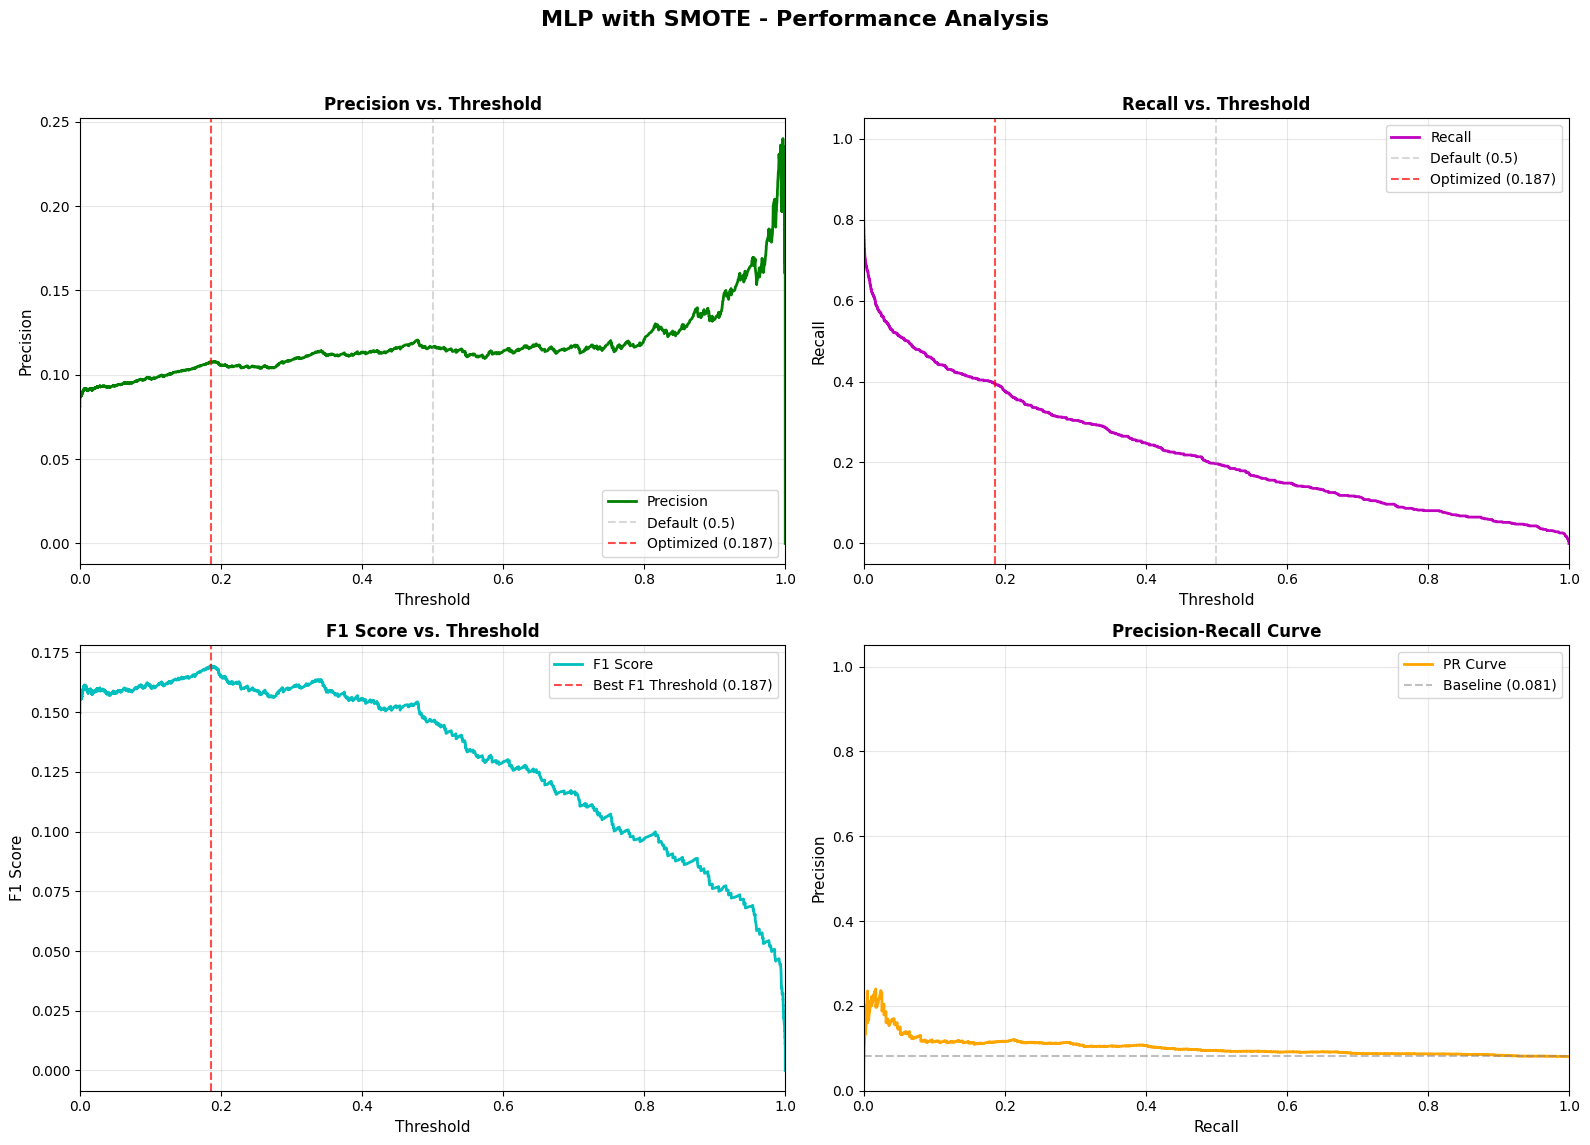


✓ Plot saved to 'mlp_smote_performance.png'
TRAINING COMPLETE


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("Preparing data...")
X.columns = X.columns.str.strip()
print(X.head(0))
# Define feature types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Handle high-cardinality categoricals (optional but recommended)
high_card_threshold = 100
high_card_cats = [col for col in categorical_features if X[col].nunique() > high_card_threshold]
categorical_features = [col for col in categorical_features if col not in high_card_cats]

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"High cardinality (excluded): {len(high_card_cats)}")
if high_card_cats:
    print(f"  Excluded columns: {high_card_cats}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Class imbalance ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

# ============================================================================
# PIPELINE WITH SMOTE
# ============================================================================
print("\nSetting up pipeline with SMOTE...")

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='drop'
)

# MLP Classifier (tuned for imbalanced data)
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100, 100, 32, 16),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    batch_size=256,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    tol=1e-4
)

# Create pipeline with SMOTE
# SMOTE creates synthetic examples of the minority class (winners)
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5)),  # Oversample to 50% winners
    ('classifier', mlp_classifier)
])

print("Pipeline structure:")
print("  1. Preprocess (impute + scale/encode)")
print("  2. SMOTE (oversample minority class to 50%)")
print("  3. MLP Classifier")

# ============================================================================
# TRAINING
# ============================================================================
print("\n" + "="*80)
print("TRAINING MLP WITH SMOTE")
print("="*80)

model_pipeline.fit(X_train, y_train)

# ============================================================================
# EVALUATION
# ============================================================================
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "="*80)
print("RESULTS WITH DEFAULT THRESHOLD (0.5)")
print("="*80)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Check probability distribution
print("\nPredicted Probability Distribution:")
print(f"  Mean: {y_pred_proba.mean():.4f}")
print(f"  Std: {y_pred_proba.std():.4f}")
print(f"  Min: {y_pred_proba.min():.4f}")
print(f"  Max: {y_pred_proba.max():.4f}")
print(f"  Predictions > 0.5: {(y_pred_proba > 0.5).sum()} ({(y_pred_proba > 0.5).mean()*100:.1f}%)")

# ============================================================================
# THRESHOLD OPTIMIZATION
# ============================================================================
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
precision, recall = precision[:-1], recall[:-1]

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

print("\n" + "="*80)
print("RESULTS WITH OPTIMIZED THRESHOLD")
print("="*80)
print(f"Optimized Threshold: {best_threshold:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

# Top 10% analysis
top_10_pct = int(len(y_pred_proba) * 0.1)
top_indices = np.argsort(y_pred_proba)[-top_10_pct:]
precision_at_10 = y_test.iloc[top_indices].mean()

print(f"\n{'='*80}")
print("BETTING STRATEGY ANALYSIS")
print("="*80)
print(f"Precision at Top 10%: {precision_at_10:.4f} ({precision_at_10*100:.1f}%)")
print(f"Baseline (random): {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)")
print(f"Improvement: {precision_at_10/y_test.mean():.2f}x")

# Check different top-k percentages
print("\nPrecision at different confidence levels:")
for pct in [5, 10, 15, 20, 25]:
    top_k = int(len(y_pred_proba) * (pct/100))
    top_k_indices = np.argsort(y_pred_proba)[-top_k:]
    prec_k = y_test.iloc[top_k_indices].mean()
    print(f"  Top {pct:2d}%: {prec_k:.4f} ({prec_k*100:.1f}% win rate) - {prec_k/y_test.mean():.2f}x baseline")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("GENERATING PLOTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MLP with SMOTE - Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Precision vs Threshold
axes[0, 0].plot(thresholds, precision, 'g-', linewidth=2, label='Precision')
axes[0, 0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.3, label='Default (0.5)')
axes[0, 0].axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7, label=f'Optimized ({best_threshold:.3f})')
axes[0, 0].set_xlabel('Threshold', fontsize=11)
axes[0, 0].set_ylabel('Precision', fontsize=11)
axes[0, 0].set_title('Precision vs. Threshold', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0.0, 1.0])

# Plot 2: Recall vs Threshold
axes[0, 1].plot(thresholds, recall, 'm-', linewidth=2, label='Recall')
axes[0, 1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.3, label='Default (0.5)')
axes[0, 1].axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7, label=f'Optimized ({best_threshold:.3f})')
axes[0, 1].set_xlabel('Threshold', fontsize=11)
axes[0, 1].set_ylabel('Recall', fontsize=11)
axes[0, 1].set_title('Recall vs. Threshold', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0.0, 1.0])

# Plot 3: F1 Score vs Threshold
axes[1, 0].plot(thresholds, f1_scores, 'c-', linewidth=2, label='F1 Score')
axes[1, 0].axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7,
                   label=f'Best F1 Threshold ({best_threshold:.3f})')
axes[1, 0].set_xlabel('Threshold', fontsize=11)
axes[1, 0].set_ylabel('F1 Score', fontsize=11)
axes[1, 0].set_title('F1 Score vs. Threshold', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0.0, 1.0])

# Plot 4: Precision-Recall Curve
axes[1, 1].plot(recall, precision, 'orange', linewidth=2, label='PR Curve')
axes[1, 1].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
axes[1, 1].set_xlabel('Recall', fontsize=11)
axes[1, 1].set_ylabel('Precision', fontsize=11)
axes[1, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='best', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('mlp_smote_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved to 'mlp_smote_performance.png'")
print("="*80)
print("TRAINING COMPLETE")
print("="*80)

Preparing data...

Missing values in X:
track_name                             0
claims                                 0
weight_clean                           0
track_name_clean                       0
race_date_clean                        0
going_clean                          111
distance_clean                         0
jockey_clean                           0
trainer_clean                          0
claims_clean                           0
age_clean                              0
performance_on_Soft_to_Heavy           0
performance_on_Good                    0
performance_on_Yielding                0
performance_on_Soft                    0
performance_on_Yielding_to_Soft        0
performance_on_Good_to_Yielding        0
performance_on_Heavy                   0
performance_on_Standard                0
performance_on_Good_to_Firm            0
going_numeric                        111
j_t                                    0
j_t_runs                               0
j_t_wins                               0
j_t_win_rate                           0
avg_position                       14820
dtype: int64

Total missing: 15042

Numeric features: 17
Categorical features: 9

Train size: 64075, Test size: 16019
Train positive rate: 0.0819, Test positive rate: 0.0819

Setting up ColumnTransformer and Pipeline with imputation...
================================================================================
TRAINING MLP MODEL VIA PIPELINE
================================================================================
/Users/jackcleary/Desktop/Github Top Picks/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")

=== MLP Results (Default Threshold of 0.5) ===
Accuracy: 0.9183
ROC-AUC Score: 0.5279

Classification Report (Default):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     14707
           1       0.83      0.00      0.01      1312

    accuracy                           0.92     16019
   macro avg       0.88      0.50      0.48     16019
weighted avg       0.91      0.92      0.88     16019


================================================================================
OPTIMIZED EVALUATION
================================================================================

=== Optimized MLP Results (Using F1-Max Threshold) ===
Optimized Threshold used: 0.0111
Accuracy: 0.1503
ROC-AUC Score: 0.5279

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.95      0.08      0.15     14707
           1       0.08      0.95      0.15      1312

    accuracy                           0.15     16019
   macro avg       0.52      0.51      0.15     16019
weighted avg       0.88      0.15      0.15     16019


Precision at Top 10%: 0.1199 (12.0%)
Baseline (random): 0.0819 (8.2%)
Improvement: 1.46x

================================================================================
GENERATING PERFORMANCE PLOTS
================================================================================